# Calibration of refractive index

Here, we use height data from Tomocube and Holomonitor to calibrate the refractive index distribution for Tomocube. 
The calibration relies on the assumption that both microscopes measure the same quantity, 
$\int dz \,\Delta \bar{n}(\rho)$, under different assumptions.

- Holomonitor assumes a constant $\bar{n}(\rho) = 1.38-1.34=0.04$, such that $\int dz \,\Delta \bar{n}(\rho) = 0.04\,\bar{h}$
- Tomocube does not assume anything about the density dependence of the RI contrast, but the measurements are not calibrated.

In [ ]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt


sys.path.append("scripts/utils/")
from file_operations import *
from SegmentedCells  import SegmentedCells
from Microscopes     import Holomonitor

In [ ]:
_2DQPI = Holomonitor()

In [ ]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets_2D = [
    "MDCK_20240301_B1-4",
    "MDCK_20240301_B2-2",
    "MDCK_20240301_B2-6",
    "MDCK_20240317_B1-1",
    "MDCK_20240319_A1-9",
    "MDCK_20240319_A1-13",
    "MDCK_20240319_A1-16",
    "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    "MDCK_20240516_A2-1", 
    "MDCK_20240516_A2-7",
    "MDCK_20240516_B1-13",
    "MDCK_20240516_B1-22"
]


In [4]:
hmean_2D     = []
densities_2D = []

for dataset in datasets_2D:

    # load data
    config = json.load(open(f"configs/{dataset}.json"))
    stack  = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, data_type="cells")
    cells  = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(frame[frame > 0]) for frame in stack])

    hmean_2D.append( hmean_tmp )
    densities_2D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK

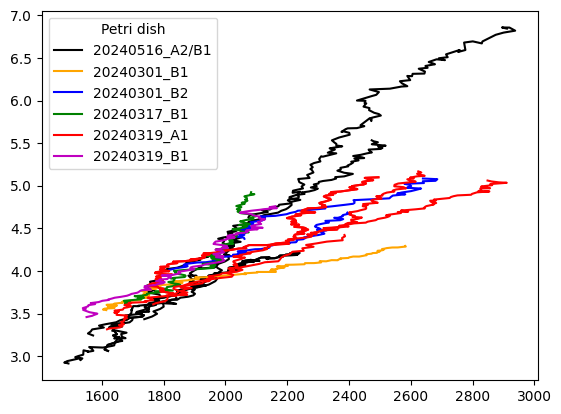

In [ ]:
shift_1 = 0
shift_2 = 0
shift_3 = 0
shift_4 = 0
shift_5 = 0

shift_1 = shift_4 = shift_5 = -.8
shift_2 = shift_3 = -1.5

plt.figure()

for h, rho, c in zip(hmean_2D[-4:],
                    densities_2D[-4:],
                    cmap_2D):
    plt.plot(rho, h, '-', c='k')

plt.plot(densities_2D[-1], hmean_2D[-1],       'k',        label="20240516_A2/B1")
plt.plot(densities_2D[0], hmean_2D[0] + shift_1, 'orange', label="20240301_B1")
plt.plot(densities_2D[1], hmean_2D[1] + shift_2, 'b',      label="20240301_B2")
plt.plot(densities_2D[2], hmean_2D[2] + shift_2, 'b')
plt.plot(densities_2D[3], hmean_2D[3] + shift_3, 'g',      label="20240317_B1")
plt.plot(densities_2D[4], hmean_2D[4] + shift_4, 'r',      label="20240319_A1")

for h, rho, c in zip(hmean_2D[4:-5],
                    densities_2D[4:-5]):
    plt.plot(rho, h+shift_4, '-', c='r')

plt.plot(densities_2D[-5], hmean_2D[-5] + shift_5, 'm', label="20240319_B1")

plt.legend(title="Petri dish")